importing & download datset

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

weather_data = pd.read_csv('Plant_1_Weather_Sensor_Data.csv')
power_data = pd.read_csv('Plant_1_Generation_Data.csv')

print("dataset downloaded")

dataset downloaded


استكشاف البيانات ودمجها (EDA)

sample of data:
            DATE_TIME  PLANT_ID_x  DC_POWER  AC_POWER  DAILY_YIELD  \
0 2020-05-15 00:00:00   4135001.0       0.0       0.0          0.0   
1 2020-05-15 01:00:00   4135001.0       0.0       0.0          0.0   
2 2020-05-15 02:00:00   4135001.0       0.0       0.0          0.0   
3 2020-05-15 03:00:00   4135001.0       0.0       0.0          0.0   
4 2020-05-15 04:00:00   4135001.0       0.0       0.0          0.0   

    TOTAL_YIELD  PLANT_ID_y  AMBIENT_TEMPERATURE  MODULE_TEMPERATURE  \
0  6.837223e+06   4135001.0            25.012697           22.643083   
1  6.845193e+06   4135001.0            24.669188           22.417802   
2  6.837223e+06   4135001.0            24.986837           23.512072   
3  6.837223e+06   4135001.0            24.954589           24.126433   
4  6.849041e+06   4135001.0            24.272046           22.127855   

   IRRADIATION  
0          0.0  
1          0.0  
2          0.0  
3          0.0  
4          0.0  


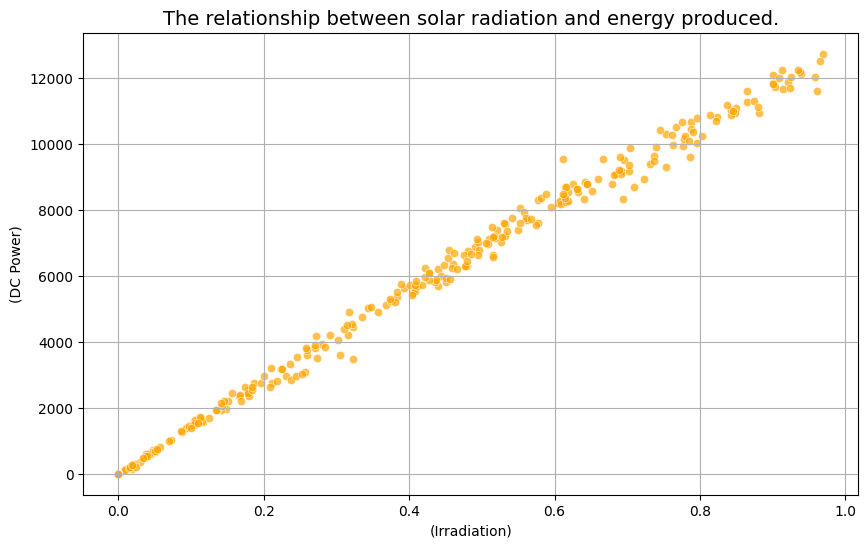

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Convert DATE_TIME to datetime format in both DataFrames before merging
power_data['DATE_TIME'] = pd.to_datetime(power_data['DATE_TIME'], format='mixed')
weather_data['DATE_TIME'] = pd.to_datetime(weather_data['DATE_TIME'], format='mixed')

# Merge datasets
df = pd.merge(power_data, weather_data, on='DATE_TIME', how='inner')

# Resample hourly
df_hourly = df.set_index('DATE_TIME').resample('1h').mean(numeric_only=True).reset_index()
df_hourly = df_hourly.dropna()

print("sample of data:")
print(df_hourly.head())

# Plot the relationship
plt.figure(figsize=(10, 6))
sns.scatterplot(x='IRRADIATION', y='DC_POWER', data=df_hourly, color='orange', alpha=0.7)
plt.title('The relationship between solar radiation and energy produced.', fontsize=14)
plt.xlabel('(Irradiation)')
plt.ylabel( '(DC Power)')
plt.grid(True)
plt.show()

تجهيز البيانات للتدريب (spliting(traning&testing)

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


X = df_hourly[['AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION']]
y = df_hourly['DC_POWER']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("done")

done


Model Training

In [4]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# تهيئة النموذج
model = RandomForestRegressor(n_estimators=100, random_state=42)

# تدريب النموذج على البيانات
print("جاري تدريب النموذج... يرجى الانتظار...")
model.fit(X_train_scaled, y_train)

# جعل النموذج يتوقع بناءً على بيانات الاختبار
y_pred = model.predict(X_test_scaled)

# تقييم الدقة
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n--- نتائج التدريب ---")
print(f"متوسط نسبة الخطأ (MAE): {mae:.2f} (كلما قل كان أفضل)")
print(f"دقة النموذج (R2 Score): {r2:.2f} (أعلى قيمة هي 1.0، فوق 0.8 يعتبر ممتاز)")

جاري تدريب النموذج... يرجى الانتظار...

--- نتائج التدريب ---
متوسط نسبة الخطأ (MAE): 86.12 (كلما قل كان أفضل)
دقة النموذج (R2 Score): 1.00 (أعلى قيمة هي 1.0، فوق 0.8 يعتبر ممتاز)


الواجهة التفاعلية (Gradio GUI)

In [ ]:
# تثبيت مكتبة gradio أولاً
!pip install gradio -q

import gradio as gr
import joblib
import numpy as np # <-- هذا هو السطر الذي أضفناه لحل المشكلة

# حفظ النموذج والـ Scaler
joblib.dump(model, 'solar_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

# دالة التوقع التي ستستخدمها الواجهة
def predict_power(ambient_temp, module_temp, irradiation):
    loaded_model = joblib.load('solar_model.pkl')
    loaded_scaler = joblib.load('scaler.pkl')

    # الآن np معرفة ويمكن استخدامها
    input_data = np.array([[ambient_temp, module_temp, irradiation]])
    input_scaled = loaded_scaler.transform(input_data)

    prediction = loaded_model.predict(input_scaled)
    final_prediction = max(0, prediction[0])
    return f"{final_prediction:.2f} واط"

# تصميم الواجهة
interface = gr.Interface(
    fn=predict_power,
    inputs=[
        gr.Slider(10, 45, value=25, label="درجة الحرارة المحيطة (مئوية)"),
        gr.Slider(10, 65, value=40, label="درجة حرارة الألواح (مئوية)"),
        gr.Slider(0.0, 1.5, value=0.5, label="كثافة الإشعاع الشمسي")
    ],
    outputs=gr.Text(label="الطاقة المتوقعة"),
    title="☀ متوقع إنتاج الطاقة الشمسية الذكي",
    description="قم بتغيير مؤشرات الطقس لتوقع كمية الطاقة التي ستنتجها الألواح.",
    theme="default"
)

# تشغيل الواجهة داخل Colab مباشرة (بدون رابط خارجي لتجنب أخطاء Time-out)
interface.launch(share=False, debug=True)


[notice] A new release of pip is available: 26.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip
c:\Users\Dell\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\Dell\AppData\Local\Programs\Python\Python313\Lib\site-packages\gradio\interface.py:171: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  super().__init__(


* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


c:\Users\Dell\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\Dell\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\Dell\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\Dell\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\Dell\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWa